# Nama: Vinsensius Carlos
# NIM: 4222301072
# Kelas: Robotika C Pagi

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [ ]:
df = pd.read_csv('WineQT.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai alcohol vs quality')

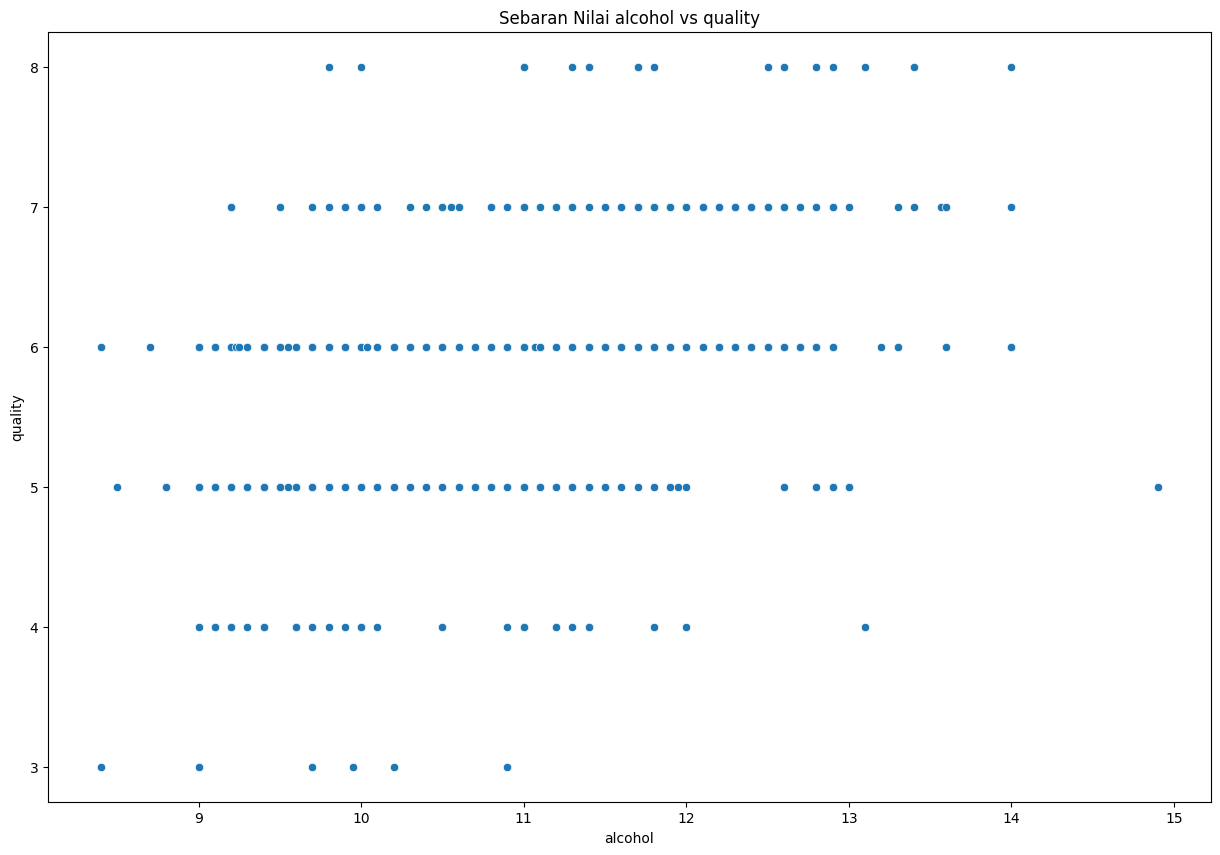

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality')
plt.title('Sebaran Nilai alcohol vs quality')

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


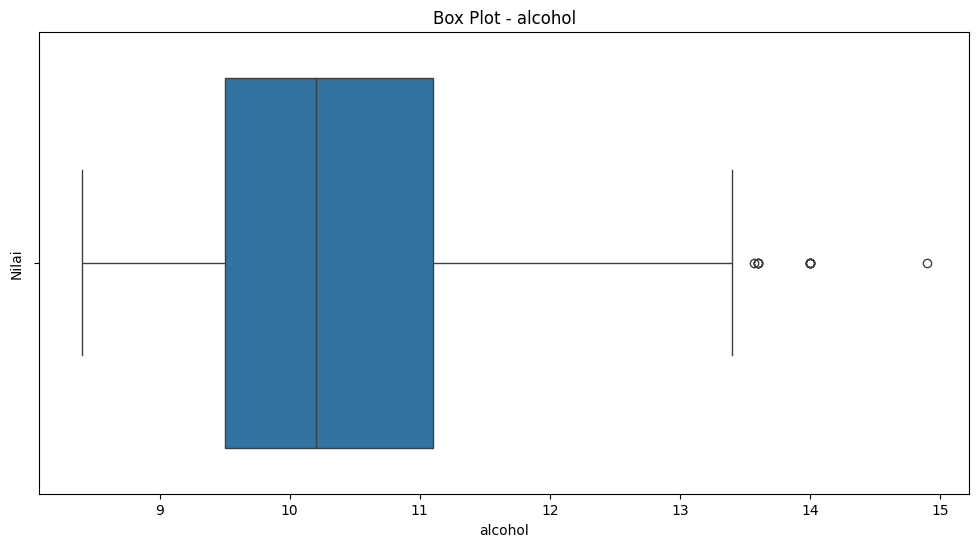

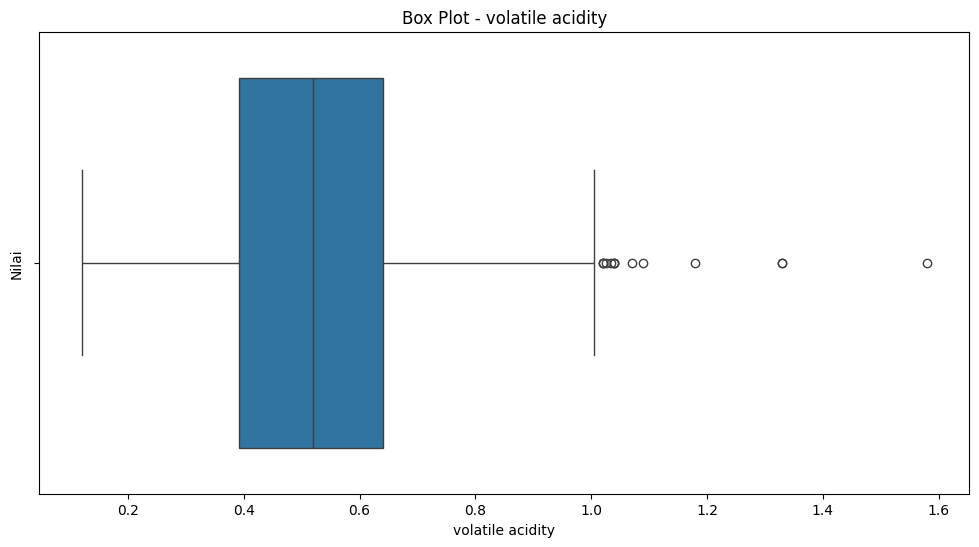

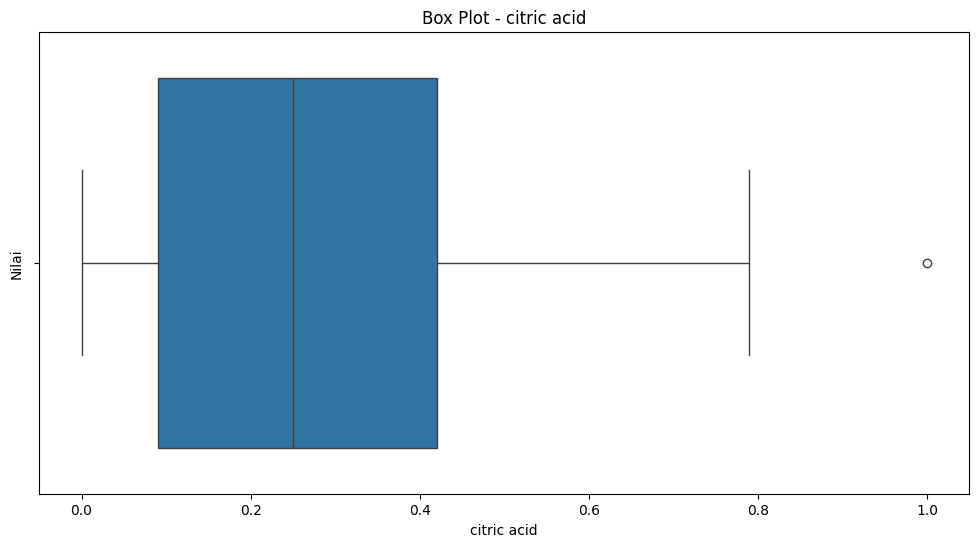

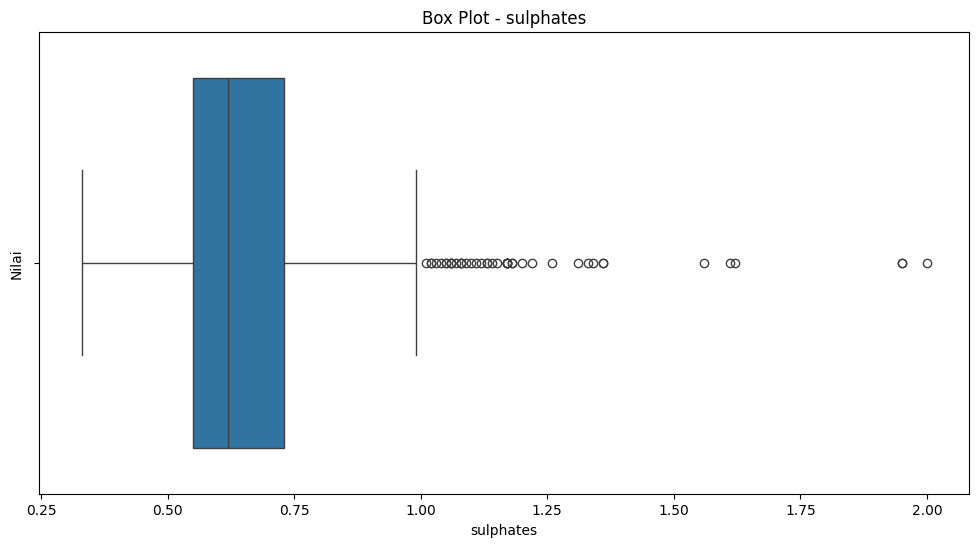

In [ ]:
columns = ['alcohol', 'volatile acidity', 'citric acid', 'sulphates']

for col in columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

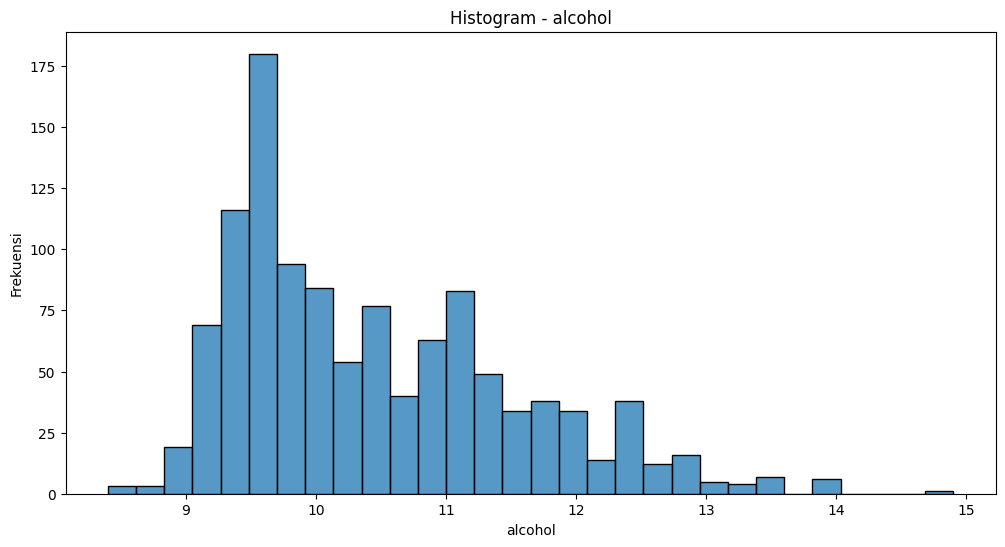

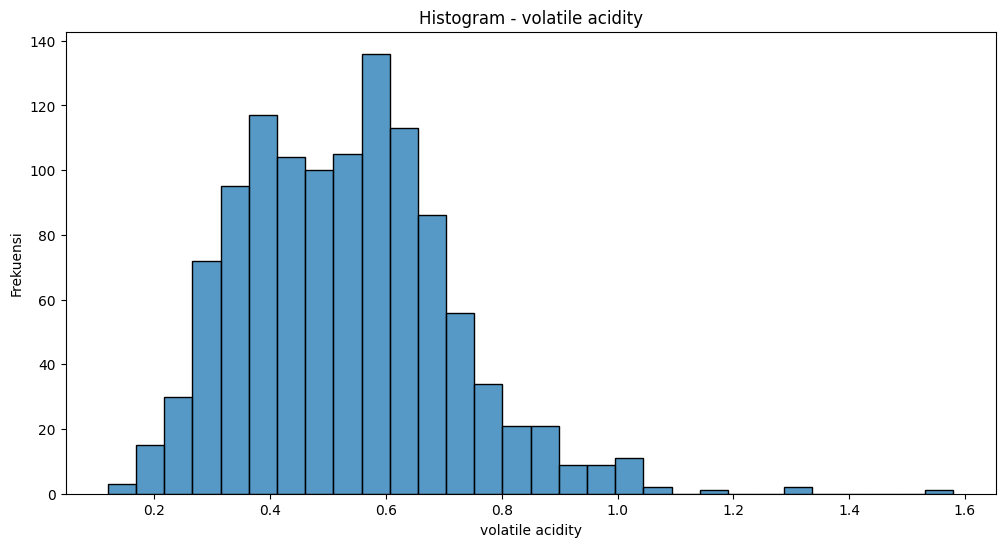

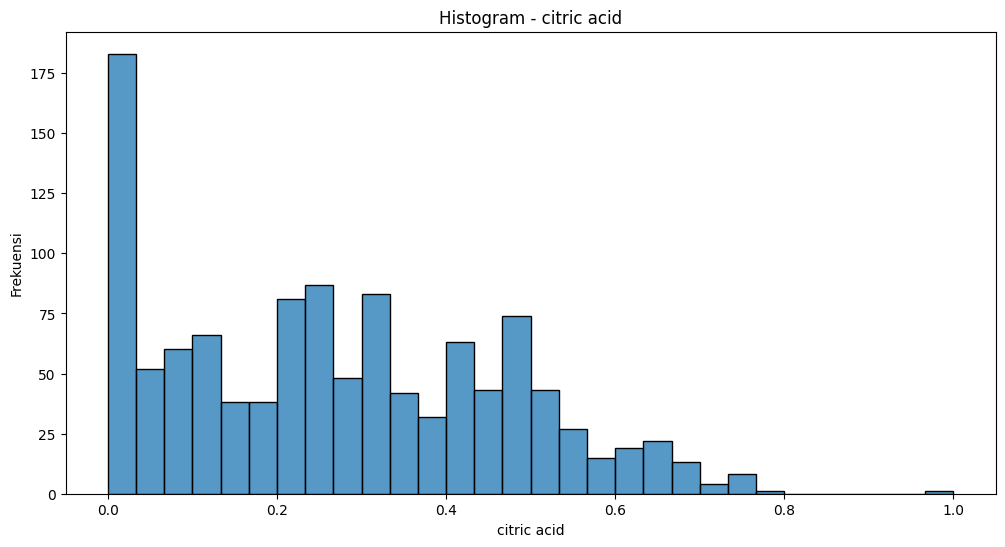

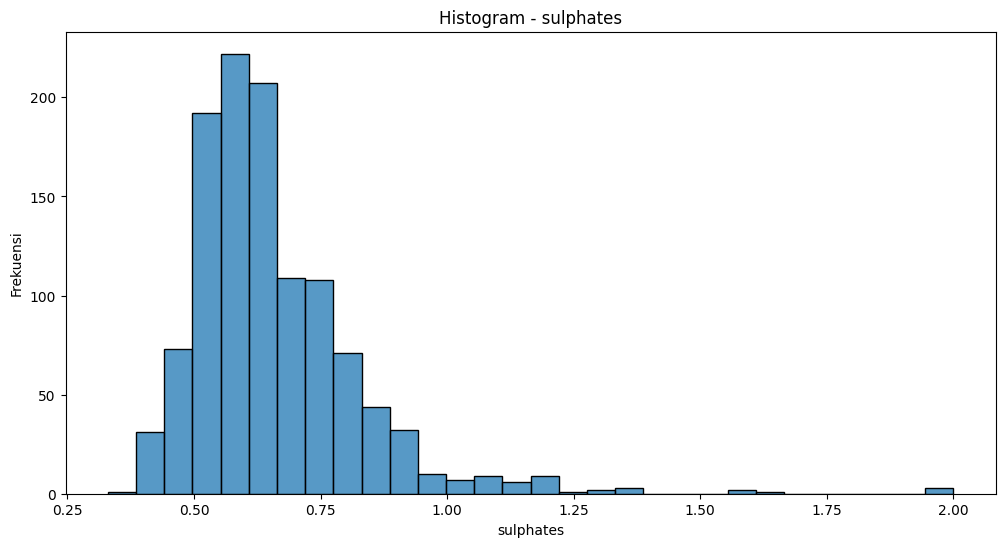

In [ ]:
for col in columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)
3. Feature Scalling

In [ ]:
print(f"Dataframe dimension before duplication drop {df.shape[0]}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


In [ ]:
fitur_columns = ['alcohol', 'volatile acidity', 'citric acid', 'sulphates',
                 'fixed acidity', 'residual sugar', 'chlorides',
                 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH']
X = df[fitur_columns].values
y = df['quality'].values  # label kualitas wine

In [ ]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data=X_std, columns=fitur_columns)
df_scalling.describe()

,alcohol,volatile acidity,citric acid,sulphates,fixed acidity,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-1.193563e-15,4.475860e-16,2.486589e-17,4.973178e-17,-3.729883e-16,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-1.887834e+00,-2.290883e+00,-1.365027e+00,-1.924024e+00,-2.124483e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00
25%,-8.709366e-01,-7.732388e-01,-9.072439e-01,-6.323694e-01,-6.933192e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01
50%,-2.238203e-01,-6.314838e-02,-9.340780e-02,-2.213884e-01,-2.353469e-01,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03
75%,6.081863e-01,6.051720e-01,7.712930e-01,4.244390e-01,4.516116e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01
max,4.121103e+00,5.840349e+00,3.721449e+00,7.880809e+00,4.344377e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00


In [ ]:
X_std

array([[-0.96338181,  0.93933222, -1.36502663, ..., -0.3636101 ,
         0.55585438,  1.27069495],
       [-0.59360107,  1.94181282, -1.36502663, ...,  0.64347653,
         0.03616459, -0.70892755],
       [-0.59360107,  1.27349242, -1.16156762, ...,  0.24674544,
         0.14010255, -0.32577481],
       ...,
       [ 0.05351522,  0.38239855, -0.9581086 , ..., -0.05843233,
        -0.95124601,  0.88754221],
       [ 0.70063152,  0.10393172, -0.8563791 , ...,  0.15519211,
        -0.83691426,  1.33455374],
       [-0.22382033,  0.6330187 , -0.75464959, ..., -0.05843233,
        -0.65502283,  1.65384769]])

In [ ]:
df_scalling

,alcohol,volatile acidity,citric acid,sulphates,fixed acidity,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH
0,-0.963382,0.939332,-1.365027,-0.573658,-0.521580,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695
1,-0.593601,1.941813,-1.365027,0.130881,-0.292593,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928
2,-0.593601,1.273492,-1.161568,-0.045254,-0.292593,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775
3,-0.593601,-1.399789,1.483400,-0.456235,1.653789,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363
4,-0.963382,0.939332,-1.365027,-0.573658,-0.521580,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695
...,...,...,...,...,...,...,...,...,...,...,...
1138,0.515741,-0.118842,-0.703785,0.541862,-1.151292,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966
1139,-0.870937,0.493785,-0.958109,0.952843,-0.865059,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966
1140,0.053515,0.382399,-0.958109,-0.456235,-1.208538,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542
1141,0.700632,0.103932,-0.856379,0.600574,-1.380278,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

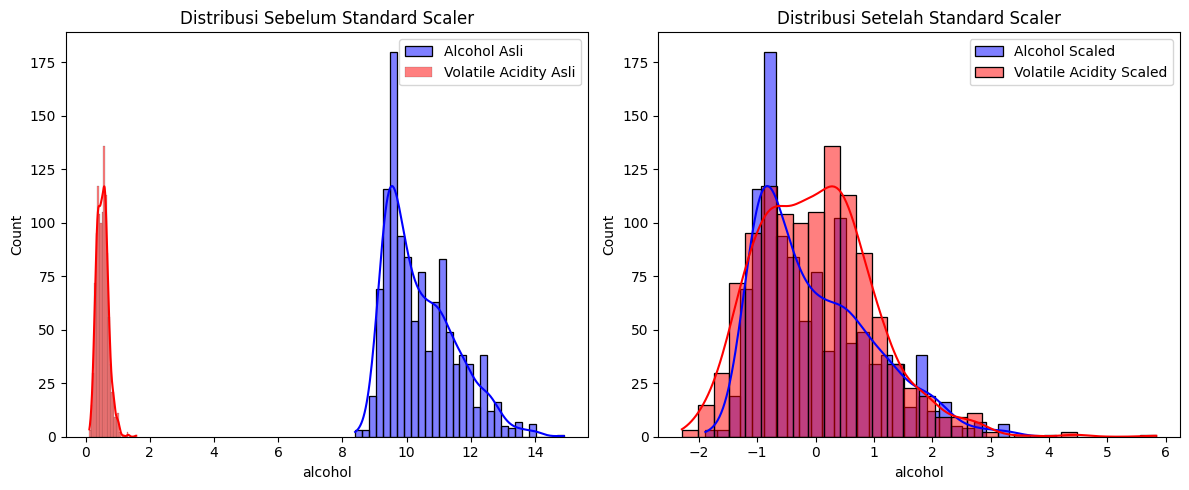

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler
sns.histplot(df['alcohol'], bins=30, kde=True, ax=ax1, color='blue', label='Alcohol Asli')
sns.histplot(df['volatile acidity'], bins=30, kde=True, ax=ax1, color='red', label='Volatile Acidity Asli')
ax1.set_title('Distribusi Sebelum Standard Scaler')
ax1.legend()

# Plot distribusi setelah Standar Scaler
sns.histplot(df_scalling['alcohol'], bins=30, kde=True, ax=ax2, color='blue', label='Alcohol Scaled')
sns.histplot(df_scalling['volatile acidity'], bins=30, kde=True, ax=ax2, color='red', label='Volatile Acidity Scaled')
ax2.set_title('Distribusi Setelah Standard Scaler')
ax2.legend()

plt.tight_layout()
plt.show()

Terlihat perubahan skala sebelum menggunakan standar scaller dan sesudah standard scaller walau masih memiliki pola yang sama. Terlihat juga distribusinya lebih simetris seperti distribusi normal.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label kualitas wine.
1. Metode Elbow
2. Via-Score Plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

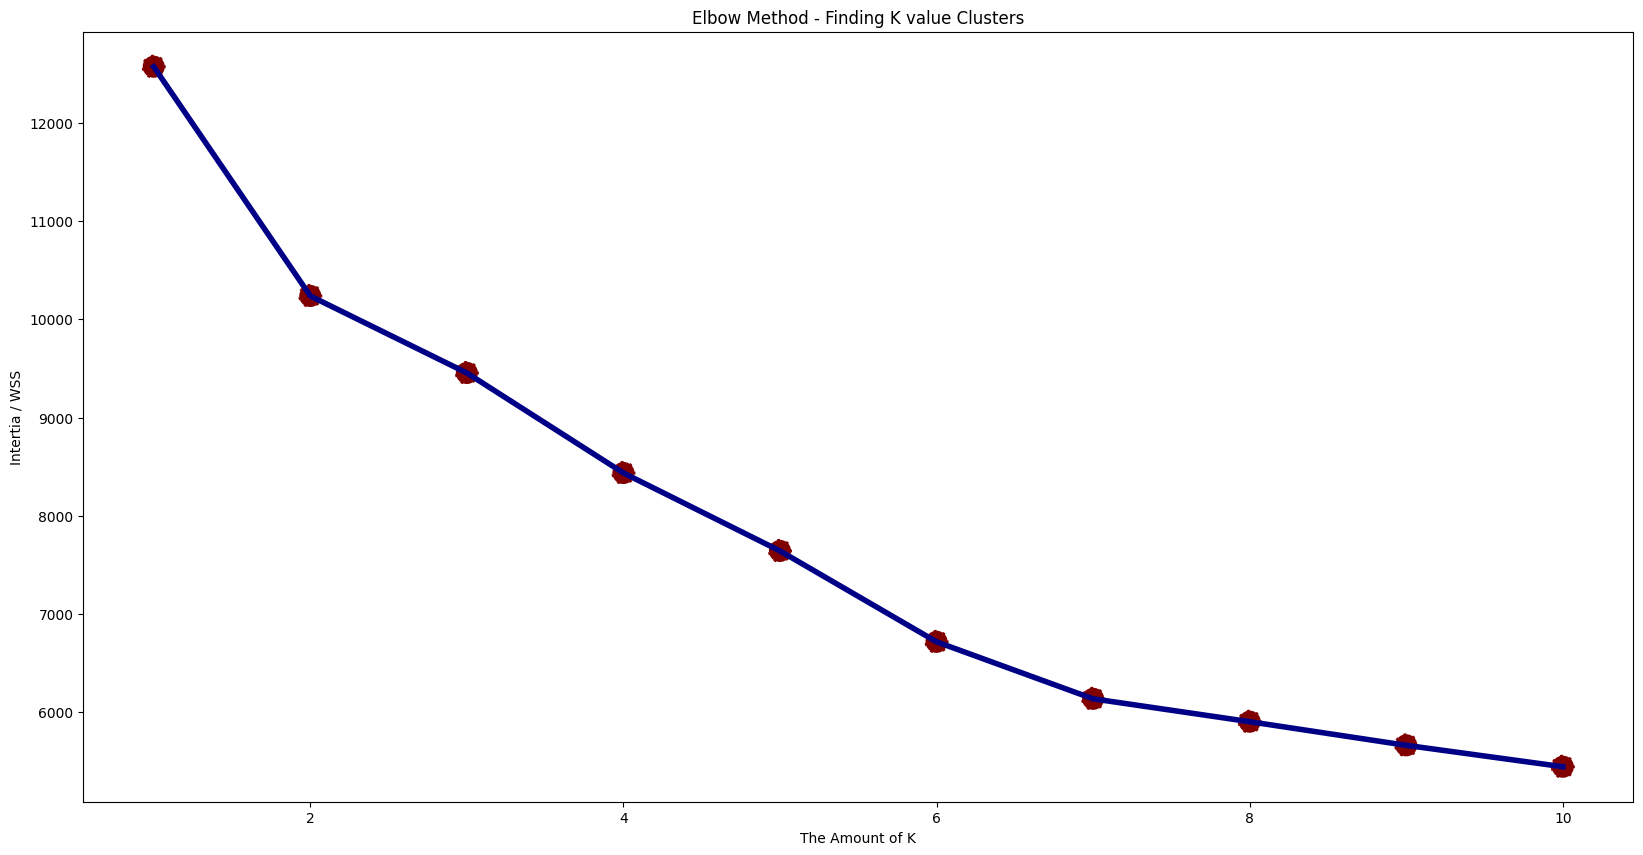

In [ ]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))
sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth=4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000', linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [ ]:
# Dari hasil diatas elbow dipilih pada angka 3
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [ ]:
# Taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [ ]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1


Text(0.5, 1.0, 'K-Means Elbow - alcohol vs quality')

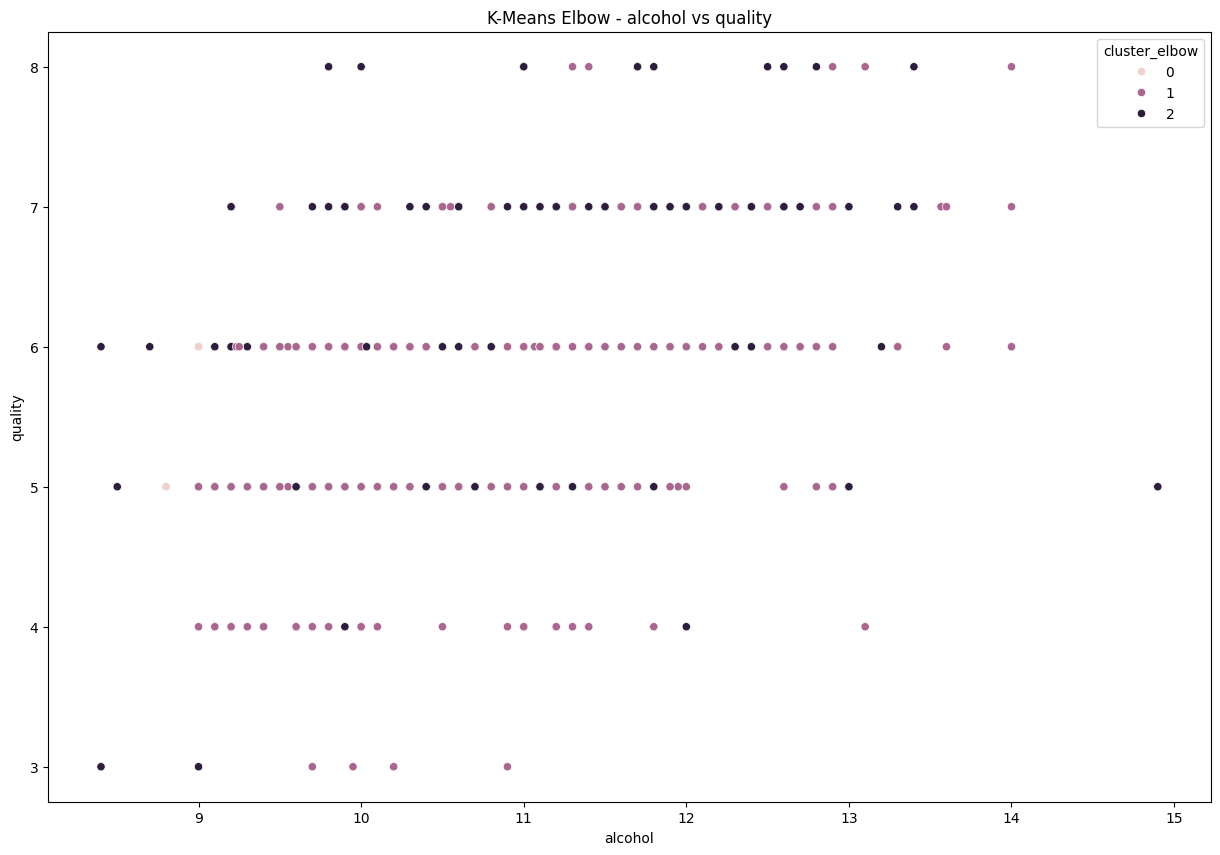

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_elbow')
plt.title('K-Means Elbow - alcohol vs quality')

### Bandingkan hasil dengan label kualitas wine

Text(0.5, 1.0, 'Distribusi Label Kualitas Wine Asli')

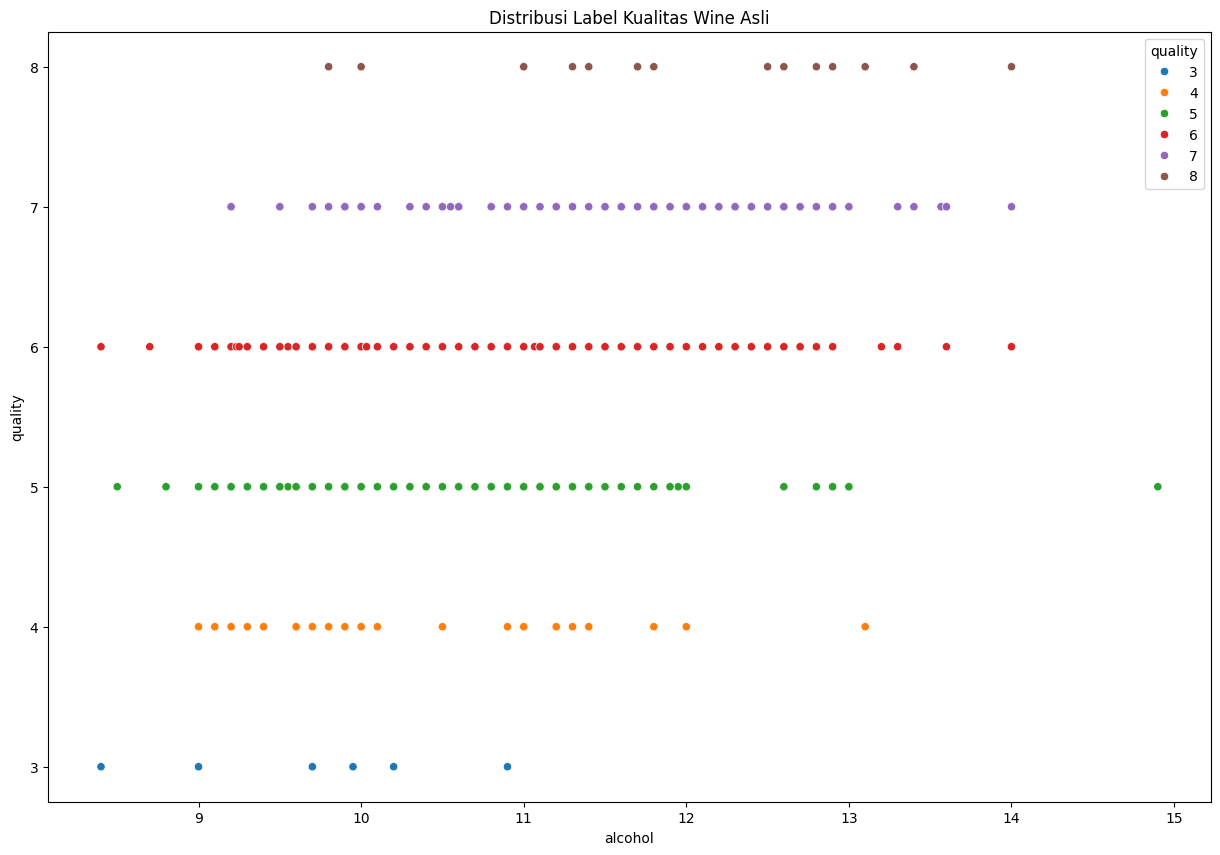

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='tab10')
plt.title('Distribusi Label Kualitas Wine Asli')

### Hasil diatas ketika menggunakan elbow ialah tidak optimal, karena cluster tidak selalu cocok dengan label kualitas asli. Dengan kondisi :
1. Cluster 0 -> Wine kualitas rendah
2. Cluster 1 -> Wine kualitas sedang
3. Cluster 2 -> Wine kualitas tinggi

### 2. Via Score Plot

In [ ]:
!pip install yellowbrick

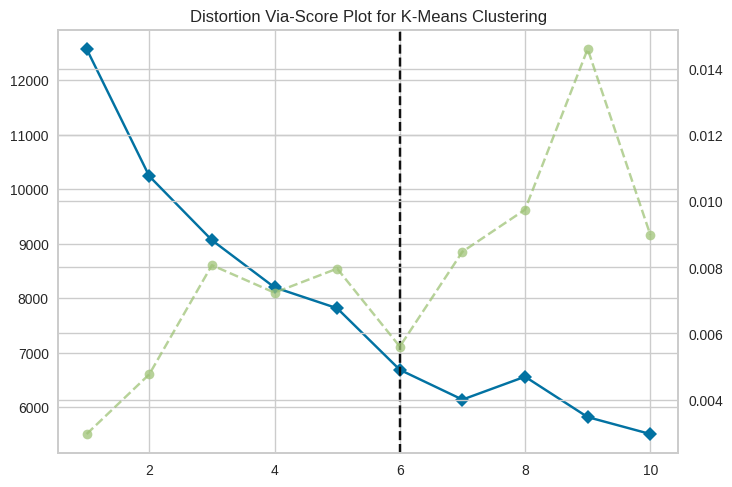

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings=True)
visualizer.fit(df_scalling.values)
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [ ]:
# Dari hasil diatas K dipilih pada angka 3
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [ ]:
# Taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [ ]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1,1


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

Text(0.5, 1.0, 'K-Means Via-Score - alcohol vs quality')

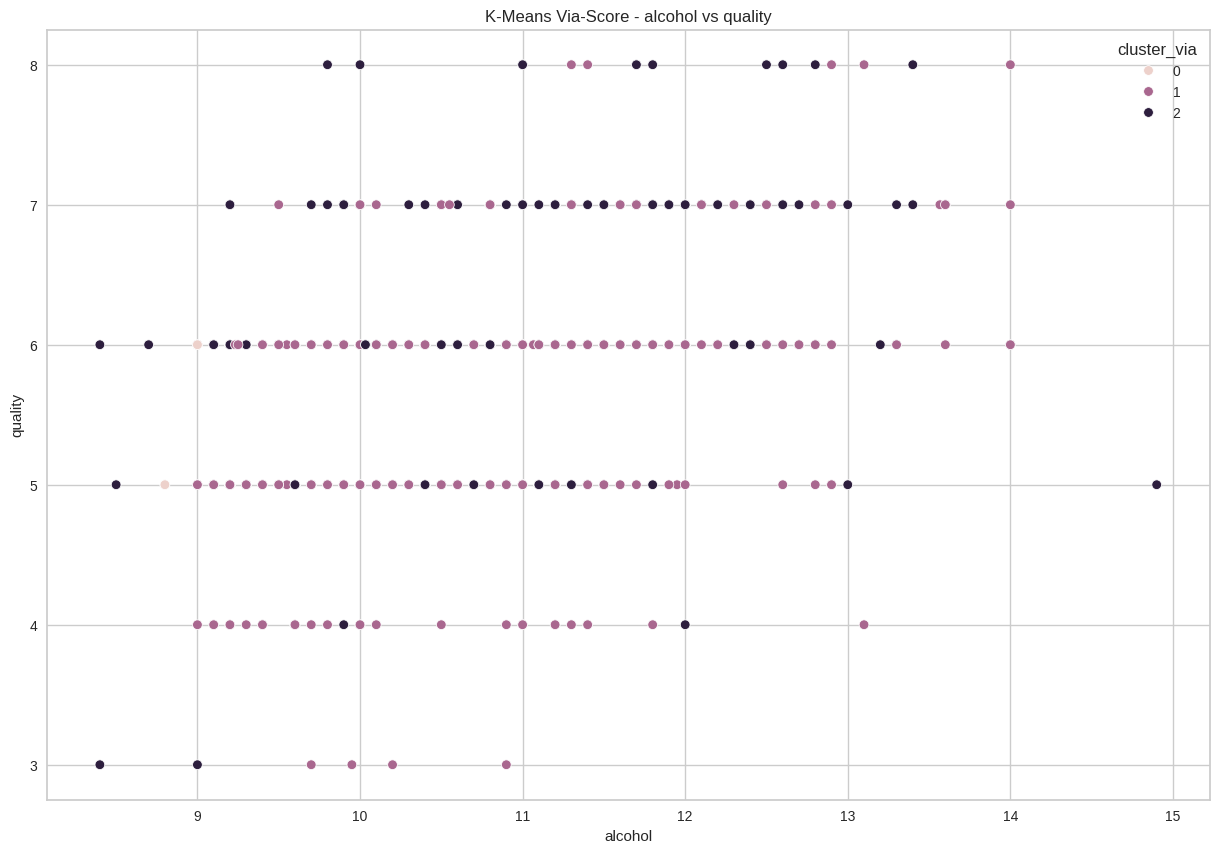

In [ ]:
# Lakukan evaluasi setelah dilakukan K-Means
# Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_via')
plt.title('K-Means Via-Score - alcohol vs quality')

### Bandingkan dengan label kualitas wine

Text(0.5, 1.0, 'Label Kualitas Wine Asli')

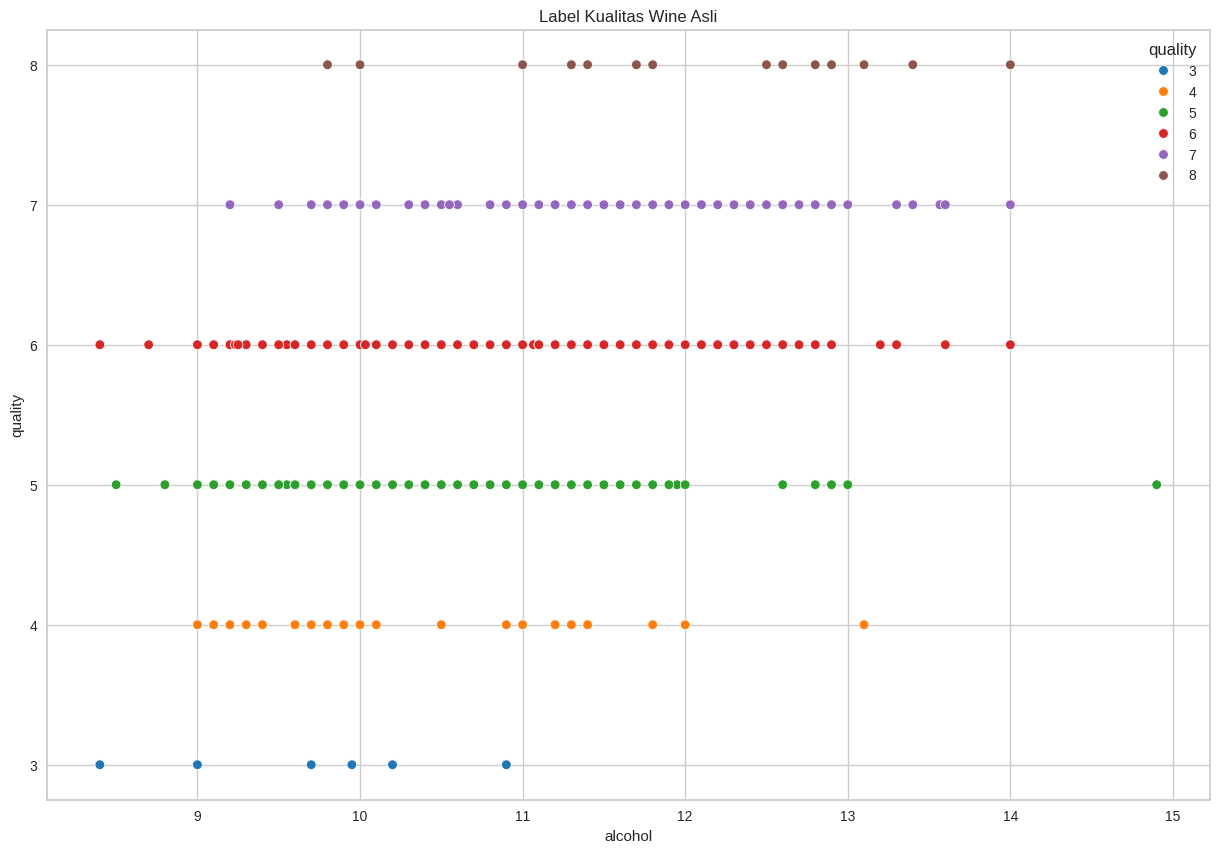

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='tab10')
plt.title('Label Kualitas Wine Asli')

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Meskipun k-means berhasil membagi data wine menjadi 3 cluster, cluster yang terbentuk tidak selalu selaras dengan label kualitas wine asli (skala 3-8).
2. Cluster dengan kadar alcohol tinggi cenderung mengelompok bersama wine berkualitas lebih tinggi.
3. Volatile acidity yang tinggi cenderung berkaitan dengan wine berkualitas rendah, sehingga fitur ini cukup informatif dalam pembentukan cluster.

Perbedaan antara hasil clustering dan label asli terjadi karena k-means hanya mempertimbangkan kedekatan jarak antar fitur numerik, sementara label kualitas wine merupakan penilaian subjektif yang melibatkan kombinasi kompleks dari banyak fitur kimia.

### Thank you :)